In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

df = yf.download("AMZN", start="2012-01-01", end="2024-01-01")
close_prices = df[["Close"]].values

scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_prices = scaler.fit_transform(close_prices)

def create_sequences(data, lookback=20):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

lookback = 20
X, y = create_sequences(scaled_prices, lookback)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(X_train_t.shape, y_train_t.shape)

[*********************100%***********************]  1 of 1 completed

torch.Size([2398, 20, 1]) torch.Size([2398, 1])


In [3]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # h0, c0: başlangıç gizli durumu ve hücre durumu, sıfırdan başlıyoruz
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size)

        out, _ = self.lstm(x, (h0, c0))   # out: (batch, seq_len, hidden_size)
        out = out[:, -1, :]               # sadece son zaman adımının çıktısını al
        out = self.fc(out)                # 1 sayıya (fiyat tahminine) indir
        return out

lstm_model = LSTMModel()
print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [4]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.gru.num_layers, x.size(0), self.gru.hidden_size)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

gru_model = GRUModel()
print(gru_model)

GRUModel(
  (gru): GRU(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [5]:
def train_model(model, X_train, y_train, epochs=100, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

    return losses

In [6]:
import time

start = time.time()
lstm_losses = train_model(lstm_model, X_train_t, y_train_t, epochs=100, lr=0.01)
lstm_time = time.time() - start
print(f"LSTM eğitim süresi: {lstm_time:.2f} saniye")

Epoch 10/100, Loss: 0.131386
Epoch 20/100, Loss: 0.019705
Epoch 30/100, Loss: 0.008265
Epoch 40/100, Loss: 0.004238
Epoch 50/100, Loss: 0.001601
Epoch 60/100, Loss: 0.001299
Epoch 70/100, Loss: 0.000807
Epoch 80/100, Loss: 0.000738
Epoch 90/100, Loss: 0.000683
Epoch 100/100, Loss: 0.000652
LSTM eğitim süresi: 8.91 saniye


In [7]:
start = time.time()
gru_losses = train_model(gru_model, X_train_t, y_train_t, epochs=100, lr=0.01)
gru_time = time.time() - start
print(f"GRU eğitim süresi: {gru_time:.2f} saniye")

Epoch 10/100, Loss: 0.003840
Epoch 20/100, Loss: 0.016204
Epoch 30/100, Loss: 0.006092
Epoch 40/100, Loss: 0.002654
Epoch 50/100, Loss: 0.001382
Epoch 60/100, Loss: 0.000872
Epoch 70/100, Loss: 0.000634
Epoch 80/100, Loss: 0.000542
Epoch 90/100, Loss: 0.000501
Epoch 100/100, Loss: 0.000466
GRU eğitim süresi: 12.82 saniye


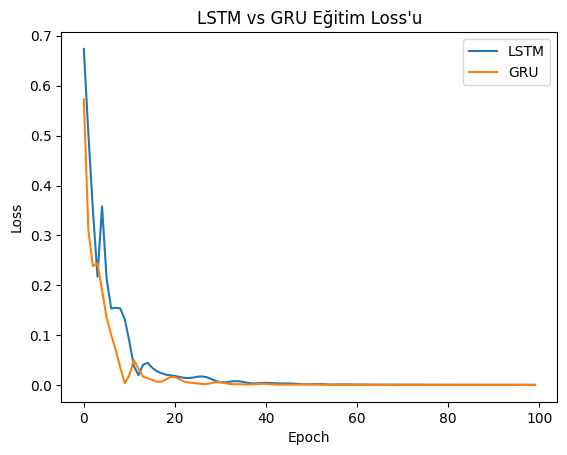

In [8]:
plt.plot(lstm_losses, label="LSTM")
plt.plot(gru_losses, label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("LSTM vs GRU Eğitim Loss'u")
plt.show()